# Exploratory Data Analysis (EDA)

This notebook explores the cleaned groundwater monitoring dataset to understand:

- Distribution of groundwater levels
- Temporal trends
- Station-wise variability
- Seasonal behavior
- Data characteristics that will guide feature engineering

The dataset used here has already undergone data cleaning and validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)

project_root = Path.cwd().resolve()
cleaned_path = None
for candidate in [project_root, project_root.parent]:
    path = candidate / "data" / "processed" / "groundwater_cleaned.csv"
    if path.exists():
        cleaned_path = path
        break

if cleaned_path is None:
    raise FileNotFoundError("groundwater_cleaned.csv not found under data/processed/.")

# Load cleaned dataset
df = pd.read_csv(cleaned_path)

# Convert timestamp
df["Data Acquisition Time"] = pd.to_datetime(
    df["Data Acquisition Time"]
)

target = "Groundwater Level Telemetry 6 Hourly (meter)"

print("Dataset Shape:", df.shape)
print("Stations:", df["Station"].nunique())
print("Date Range:")
print(df["Data Acquisition Time"].min())
print(df["Data Acquisition Time"].max())
print("Source:", cleaned_path)

df.head()

Dataset Shape: (99445, 7)
Stations: 25
Date Range:
2021-09-27 00:00:00
2025-12-30 18:00:00
Source: /workspaces/groundwater-ai/data/processed/groundwater_cleaned.csv


,Station,Data Acquisition Time,Latitude,Longitude,Groundwater Level Telemetry 6 Hourly (meter),RL_MSL,time_diff
0,Adakamaranahalli,2021-09-27 00:00:00,13.07,77.45,-22.51,849.0,NaN
1,Adakamaranahalli,2021-09-27 06:00:00,13.07,77.45,-22.87,849.0,0 days 06:00:00
2,Adakamaranahalli,2021-09-27 12:00:00,13.07,77.45,-23.23,849.0,0 days 06:00:00
3,Adakamaranahalli,2021-09-27 18:00:00,13.07,77.45,-22.66,849.0,0 days 06:00:00
4,Adakamaranahalli,2021-09-28 00:00:00,13.07,77.45,-22.46,849.0,0 days 06:00:00


## Step 2: Overall Target Distribution

This section examines the overall distribution of the groundwater level target variable.

The analysis includes:

- Summary statistics
- Histogram
- Kernel Density Estimate (KDE)
- Boxplot

This helps identify the distribution shape, spread, and any remaining extreme observations after data cleaning.

In [2]:
# Summary statistics

print(df[target].describe())

count    99445.000000
mean       -25.228653
std         36.196832
min       -190.106000
25%        -28.843000
50%        -18.321000
75%        -10.298000
max         79.026000
Name: Groundwater Level Telemetry 6 Hourly (meter), dtype: float64


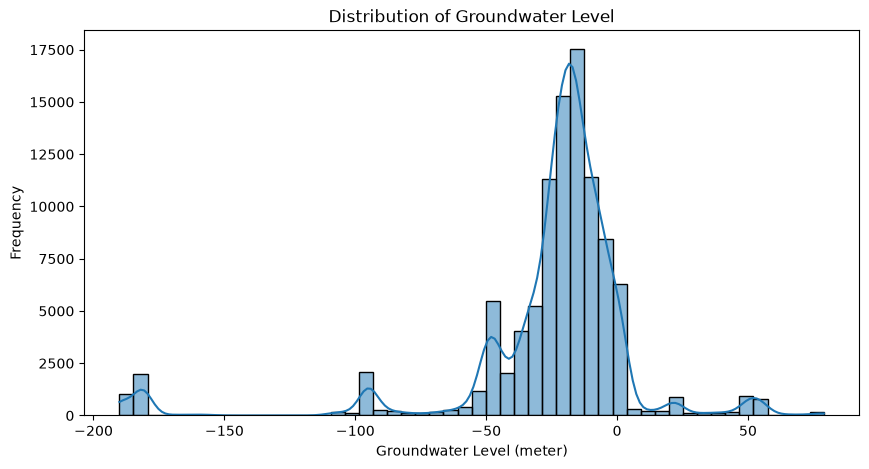

In [3]:
# Histogram + KDE

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x=target,
    bins=50,
    kde=True
)

plt.title("Distribution of Groundwater Level")
plt.xlabel("Groundwater Level (meter)")
plt.ylabel("Frequency")

plt.show()

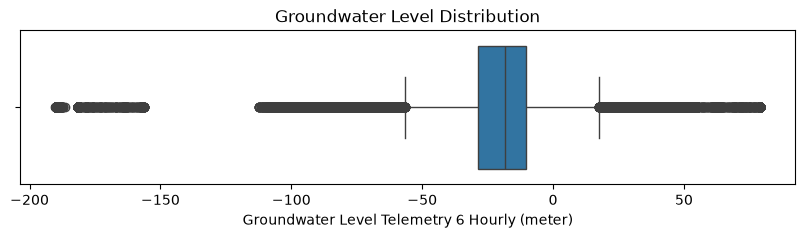

In [4]:
# Boxplot

plt.figure(figsize=(10,2))

sns.boxplot(
    x=df[target]
)

plt.title("Groundwater Level Distribution")

plt.show()

## Step 3: Station-wise Groundwater Level Distribution

Groundwater depth is expected to vary considerably across monitoring stations due to differences in local geology, recharge conditions, and aquifer characteristics.

This section compares the target distribution across stations using descriptive statistics and boxplots.

In [5]:
# Station-wise descriptive statistics

station_stats = (
    df.groupby("Station")[target]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std",
          minimum="min",
          maximum="max"
      )
      .round(2)
      .sort_values("median")
)

station_stats

,count,mean,median,std,minimum,maximum
Station,,,,,,
K Narayanapura,3317,-174.76,-181.34,38.55,-190.11,1.00
Avalahalli,3110,-74.55,-94.84,33.46,-95.49,1.00
Doddakannahalli,4345,-44.39,-49.12,9.49,-50.34,1.00
Anekal_1,3007,-48.25,-48.30,5.41,-63.47,1.00
Jakkur_1,3721,-48.96,-42.09,27.80,-112.35,1.00
Byadarahalli,4612,-31.45,-34.28,9.05,-37.96,48.36
Rajanukunte,4107,-27.39,-28.70,8.92,-49.19,1.00
Thotagere,3072,-26.83,-25.74,5.36,-39.76,1.00
Sarjapura_1,4657,-26.67,-24.80,12.28,-66.41,1.00


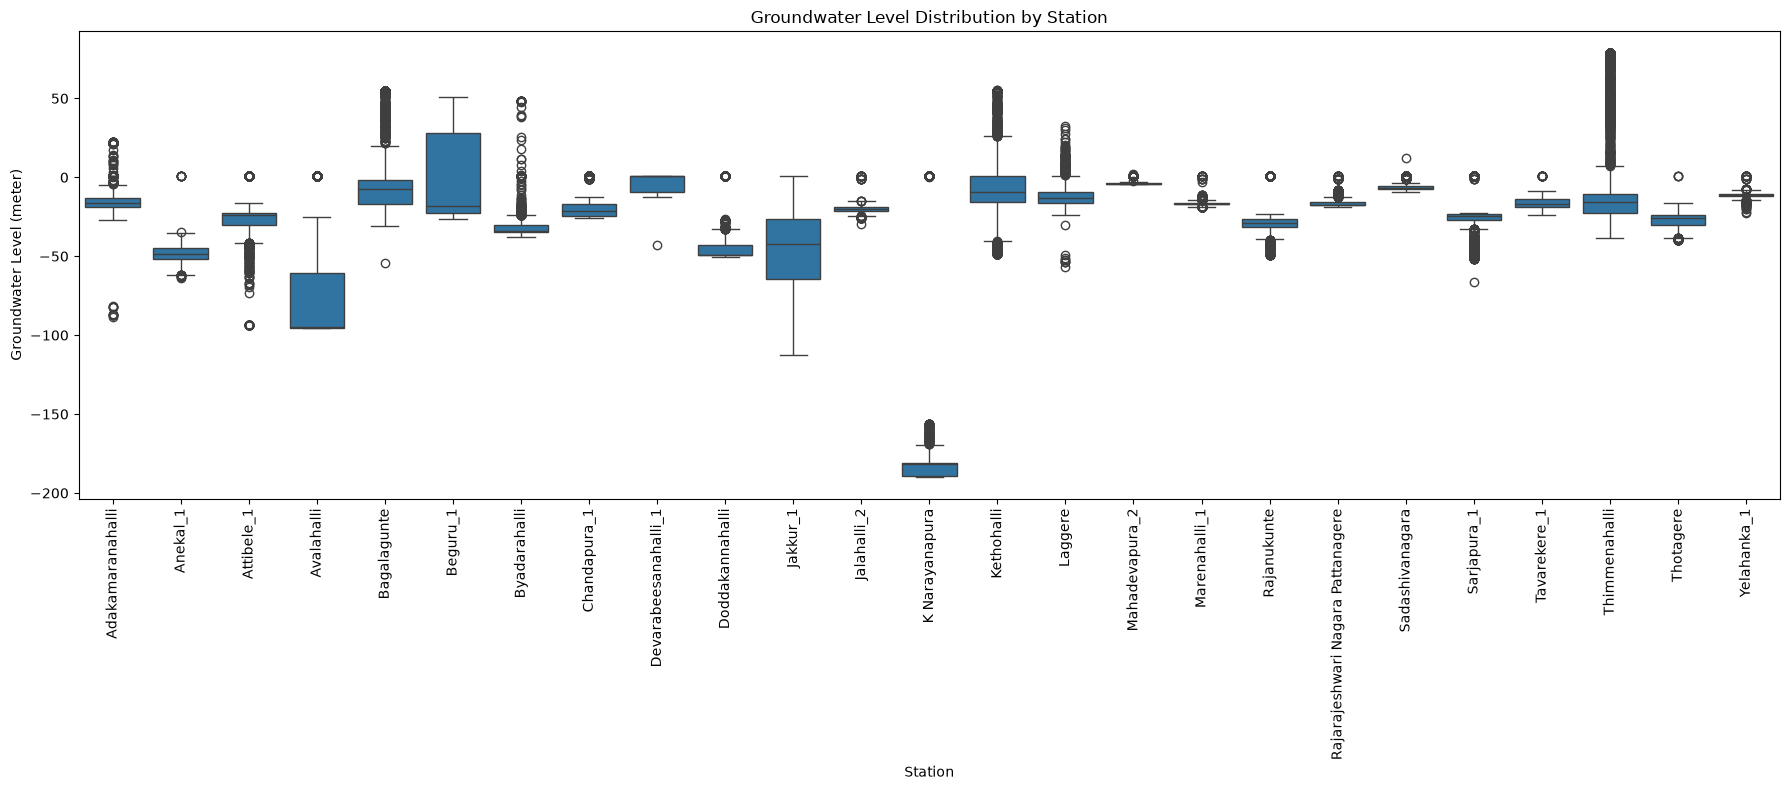

In [6]:
# Station-wise boxplots

plt.figure(figsize=(18,8))

sns.boxplot(
    data=df,
    x="Station",
    y=target
)

plt.xticks(rotation=90)

plt.title("Groundwater Level Distribution by Station")
plt.xlabel("Station")
plt.ylabel("Groundwater Level (meter)")

plt.tight_layout()
plt.show()

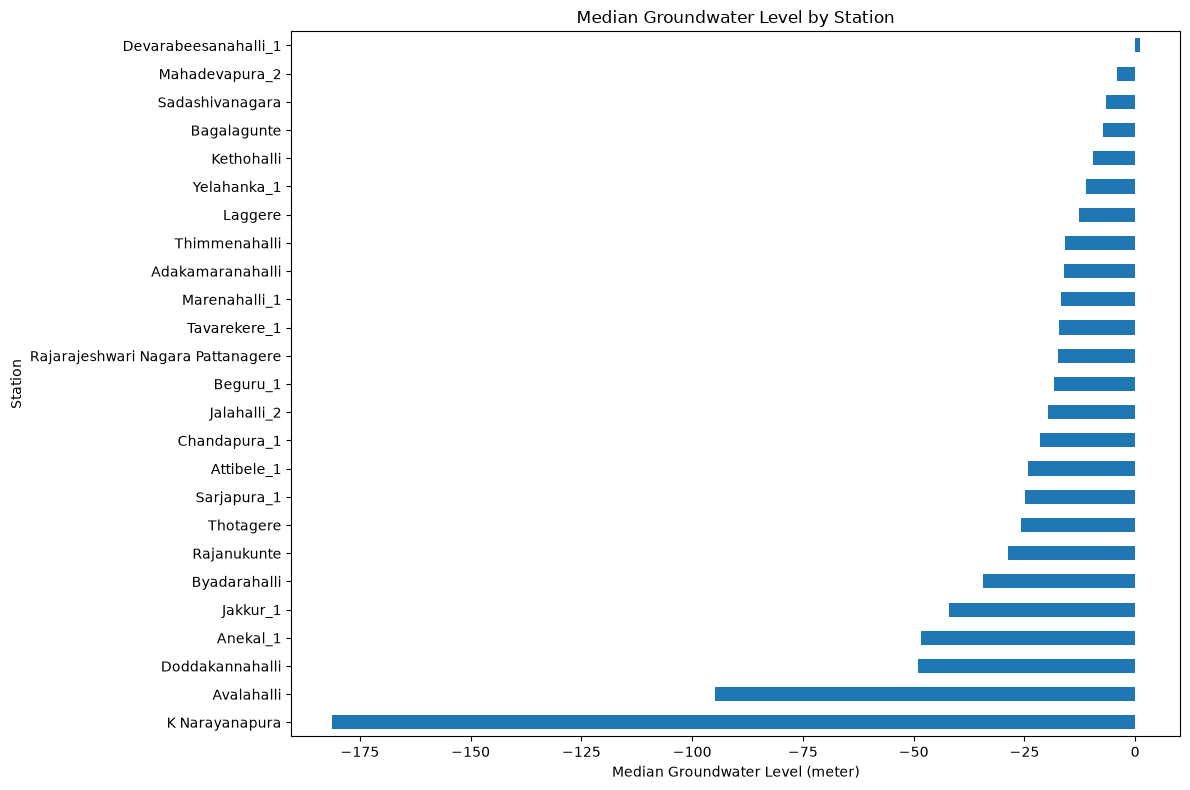

In [7]:
# Station-wise median groundwater level

plt.figure(figsize=(12,8))

station_stats["median"].sort_values().plot(kind="barh")

plt.title("Median Groundwater Level by Station")
plt.xlabel("Median Groundwater Level (meter)")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

## 3. Groundwater Level Across Stations

Groundwater level measurements were compared across all monitoring stations to understand spatial variation in groundwater conditions.

This analysis helps answer:

- Do different stations have different groundwater regimes?
- Which stations have the deepest and shallowest groundwater?
- Which stations exhibit the highest variability?
- Are positive groundwater values concentrated at particular stations?

The analysis includes:

- Boxplots for each station
- Median groundwater level comparison
- Station-wise descriptive statistics

In [8]:
station_stats = (
    df.groupby('Station')['Groundwater Level Telemetry 6 Hourly (meter)']
      .agg(
          count='count',
          mean='mean',
          median='median',
          std='std',
          minimum='min',
          maximum='max'
      )
      .round(2)
      .sort_values('median')
)

station_stats

,count,mean,median,std,minimum,maximum
Station,,,,,,
K Narayanapura,3317,-174.76,-181.34,38.55,-190.11,1.00
Avalahalli,3110,-74.55,-94.84,33.46,-95.49,1.00
Doddakannahalli,4345,-44.39,-49.12,9.49,-50.34,1.00
Anekal_1,3007,-48.25,-48.30,5.41,-63.47,1.00
Jakkur_1,3721,-48.96,-42.09,27.80,-112.35,1.00
Byadarahalli,4612,-31.45,-34.28,9.05,-37.96,48.36
Rajanukunte,4107,-27.39,-28.70,8.92,-49.19,1.00
Thotagere,3072,-26.83,-25.74,5.36,-39.76,1.00
Sarjapura_1,4657,-26.67,-24.80,12.28,-66.41,1.00


### Observations

Several important spatial patterns are visible:

- Groundwater levels vary substantially across stations.
- K Narayanapura has the deepest groundwater levels with a median around **−181 m**.
- Avalahalli also exhibits consistently deep groundwater levels.
- Stations such as Mahadevapura_2, Sadashivanagara and Devarabeesanahalli_1 show groundwater levels close to the surface.
- Several stations display wide variability, indicating seasonal fluctuations or local hydrogeological differences.
- Positive groundwater values occur primarily at a few stations and should not automatically be considered anomalies because they are geographically localized.

These findings indicate that groundwater behaviour is strongly station-dependent, suggesting that **Station** should be retained as an important predictive feature.

In [9]:
(
    df[df['Groundwater Level Telemetry 6 Hourly (meter)'] == 1]
    .groupby('Station')
    .size()
    .sort_values(ascending=False)
)

Station
Devarabeesanahalli_1                 1862
Mahadevapura_2                        566
Sarjapura_1                           426
Avalahalli                            378
Sadashivanagara                       309
Rajanukunte                           296
Chandapura_1                          267
Thimmenahalli                         260
Adakamaranahalli                      178
K Narayanapura                        148
Attibele_1                            130
Doddakannahalli                       119
Byadarahalli                           80
Beguru_1                               47
Yelahanka_1                            37
Kethohalli                             36
Jalahalli_2                            35
Rajarajeshwari Nagara Pattanagere      32
Marenahalli_1                          24
Tavarekere_1                           21
Bagalagunte                            18
Anekal_1                                8
Jakkur_1                                3
Thotagere                 

### Additional Observation

Several stations contain groundwater readings equal to **1.00 meter**.

The value is not uniformly distributed across the dataset; instead, it is concentrated in specific stations such as Devarabeesanahalli_1 and Mahadevapura_2.

Because these values occur consistently within particular stations rather than randomly across the dataset, they are not treated as data-entry errors at this stage. They are retained for subsequent temporal analysis and model development.

In [10]:
one_values = df[df['Groundwater Level Telemetry 6 Hourly (meter)'] == 1]

one_values.groupby('Station').agg(
    First_Date=('Data Acquisition Time', 'min'),
    Last_Date=('Data Acquisition Time', 'max'),
    Count=('Groundwater Level Telemetry 6 Hourly (meter)', 'count')
).sort_values('Count', ascending=False)

,First_Date,Last_Date,Count
Station,,,
Devarabeesanahalli_1,2022-08-15 00:00:00,2025-12-30 18:00:00,1862
Mahadevapura_2,2022-08-27 18:00:00,2025-12-13 00:00:00,566
Sarjapura_1,2022-05-31 18:00:00,2025-12-30 06:00:00,426
Avalahalli,2022-11-22 12:00:00,2025-12-27 00:00:00,378
Sadashivanagara,2022-06-01 00:00:00,2025-12-30 00:00:00,309
Rajanukunte,2022-05-29 06:00:00,2025-08-24 06:00:00,296
Chandapura_1,2022-06-04 06:00:00,2025-12-30 18:00:00,267
Thimmenahalli,2022-05-30 00:00:00,2025-12-03 06:00:00,260
Adakamaranahalli,2022-07-07 18:00:00,2025-12-03 12:00:00,178


### Observation on Groundwater Value = 1.00

A station-wise investigation was conducted for groundwater measurements equal to **1.00 meter**.

The analysis showed that these values occur repeatedly over long periods (2022–2025) rather than during isolated events.

Since the observations are consistently recorded over multiple years and are concentrated within specific stations, they are retained as valid measurements instead of being treated as erroneous sensor readings.

These values may represent legitimate groundwater conditions or station-specific sensor characteristics and therefore are preserved for subsequent analysis.

## 4. Temporal Analysis

Understanding the temporal behavior of groundwater levels is essential before building forecasting models.

This section investigates how groundwater levels vary throughout the observation period and identifies long-term trends, sudden changes, and unusual events.

### 4.1 Overall Groundwater Trend

The average groundwater level across all monitoring stations is calculated for each timestamp and visualized as a time series.

This helps identify:

- Long-term increasing or decreasing trends
- Seasonal fluctuations
- Abrupt anomalies
- Periods with unusual groundwater behavior

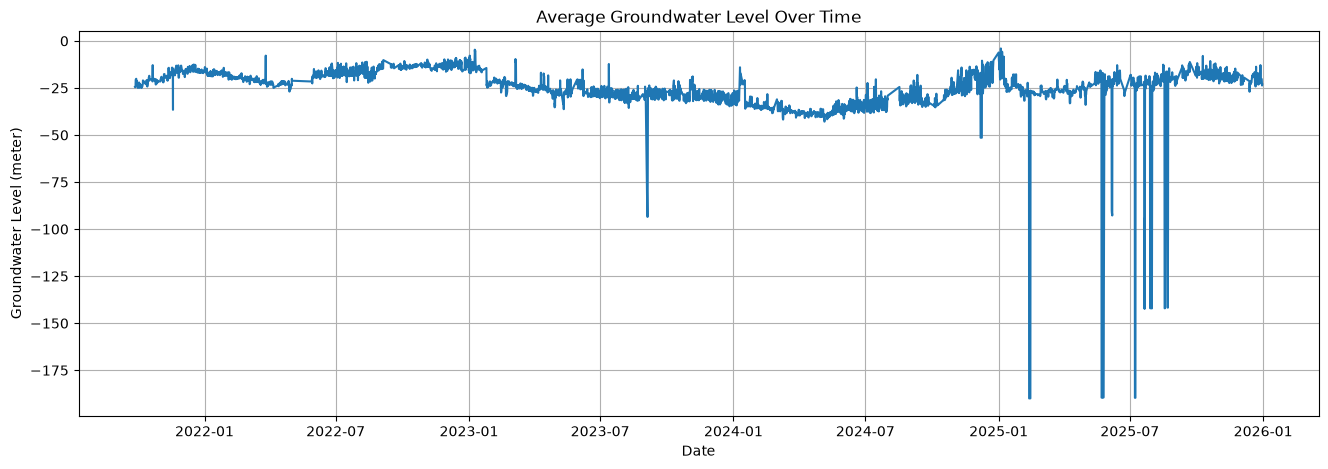

In [11]:
plt.figure(figsize=(16,5))

daily = (
    df.groupby('Data Acquisition Time')
      ['Groundwater Level Telemetry 6 Hourly (meter)']
      .mean()
)

plt.plot(daily.index, daily.values)

plt.title('Average Groundwater Level Over Time')
plt.xlabel('Date')
plt.ylabel('Groundwater Level (meter)')
plt.grid(True)
plt.show()

### Interpretation

The average groundwater level exhibits noticeable temporal variation throughout the study period.

Key observations include:

- Groundwater levels remain relatively stable between approximately **−10 m and −35 m** for most of the observation period.
- A gradual decline is observed during portions of **2023 and early 2024**, indicating deeper groundwater levels.
- Groundwater levels recover during late 2024 before stabilizing again.
- Several sharp downward spikes are visible, particularly during **2025**, reaching values close to **−190 m**.
- Since these extreme values correspond to valid station observations retained during data cleaning, they likely represent station-specific measurements rather than data-entry errors.

Overall, the dataset demonstrates clear temporal variability, suggesting that groundwater levels are influenced by seasonal recharge, climatic conditions, and station-specific hydrogeological characteristics.

### Conclusion

The overall groundwater time series indicates that groundwater behavior changes over time and is not stationary.

Both gradual trends and abrupt changes are present, highlighting the importance of incorporating temporal features into predictive models.

Further investigation at monthly, seasonal, yearly, and station levels is required to better understand these temporal patterns.

### 4.2 Monthly Trend Analysis

Groundwater levels often exhibit seasonal patterns driven by rainfall, recharge, evapotranspiration, and groundwater extraction.

To investigate these seasonal effects, the month is extracted from each observation timestamp, and the average groundwater level is computed for each calendar month across all years.

This analysis helps identify:

- Months with relatively higher groundwater levels
- Months with relatively lower groundwater levels
- Seasonal recharge and depletion patterns

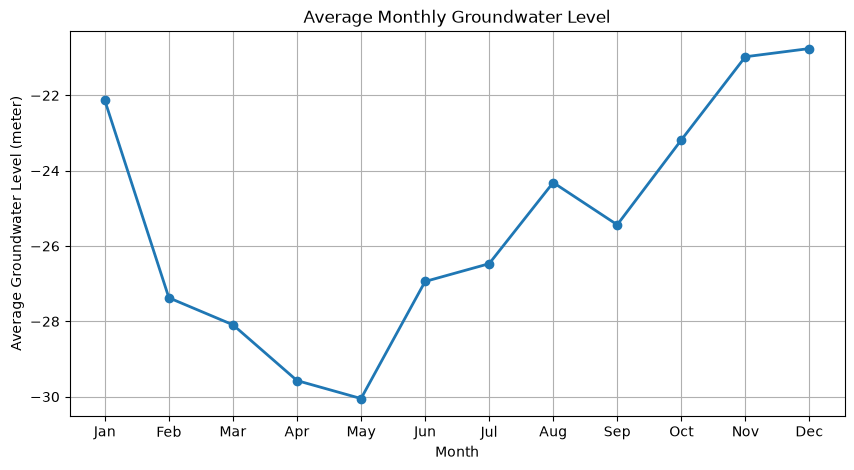

Month
1    -22.14
2    -27.37
3    -28.09
4    -29.57
5    -30.05
6    -26.94
7    -26.47
8    -24.32
9    -25.44
10   -23.19
11   -20.98
12   -20.76
Name: Groundwater Level Telemetry 6 Hourly (meter), dtype: float64

In [12]:
# Create month column
df['Month'] = df['Data Acquisition Time'].dt.month

# Monthly average groundwater level
monthly_avg = (
    df.groupby('Month')['Groundwater Level Telemetry 6 Hourly (meter)']
      .mean()
)

# Month names
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))
plt.plot(monthly_avg.index, monthly_avg.values,
         marker='o', linewidth=2)

plt.xticks(range(1,13), month_names)
plt.xlabel('Month')
plt.ylabel('Average Groundwater Level (meter)')
plt.title('Average Monthly Groundwater Level')
plt.grid(True)

plt.show()

# Display values
monthly_avg.round(2)

### Interpretation

The monthly analysis reveals a distinct seasonal pattern in groundwater levels.

Key observations include:

- The average groundwater level gradually declines from **January (-22.14 m)** to **May (-30.05 m)**, indicating progressive groundwater depletion during the dry season.
- Groundwater levels begin recovering from **June onwards**, coinciding with the onset of the monsoon season.
- A slight decline is observed in **September**, after which groundwater levels continue to improve.
- The highest average groundwater levels occur during **November (-20.98 m)** and **December (-20.76 m)**, suggesting significant groundwater recharge following the monsoon.
- The difference between the monthly maximum and minimum average groundwater levels is approximately **9.3 meters**, indicating substantial seasonal variation across the study period.

Overall, the monthly trend demonstrates a recurring annual cycle of groundwater depletion followed by recharge, confirming that seasonality is an important characteristic of the dataset.

### Conclusion

The groundwater dataset exhibits a clear seasonal pattern, with the lowest average groundwater levels occurring during **April–May** and the highest levels during **November–December**.

These observations indicate that groundwater levels are strongly influenced by seasonal climatic conditions, particularly rainfall and groundwater recharge.

The identified seasonality suggests that temporal variables such as **month** and **season** are likely to be informative features for subsequent predictive modeling.

## 4.3 Station-wise Temporal Trends

Groundwater behavior can vary considerably across monitoring stations due to differences in geology, recharge conditions, groundwater extraction, and surrounding land use.

To understand these spatial-temporal variations, the average groundwater level is visualized separately for each station over time.

This analysis helps identify:

- Long-term increasing or decreasing groundwater trends.
- Stable versus highly variable monitoring stations.
- Seasonal fluctuations within individual stations.
- Stations exhibiting abnormal behavior that may require further investigation.

These observations are valuable for selecting appropriate forecasting models and understanding spatial heterogeneity in groundwater dynamics.

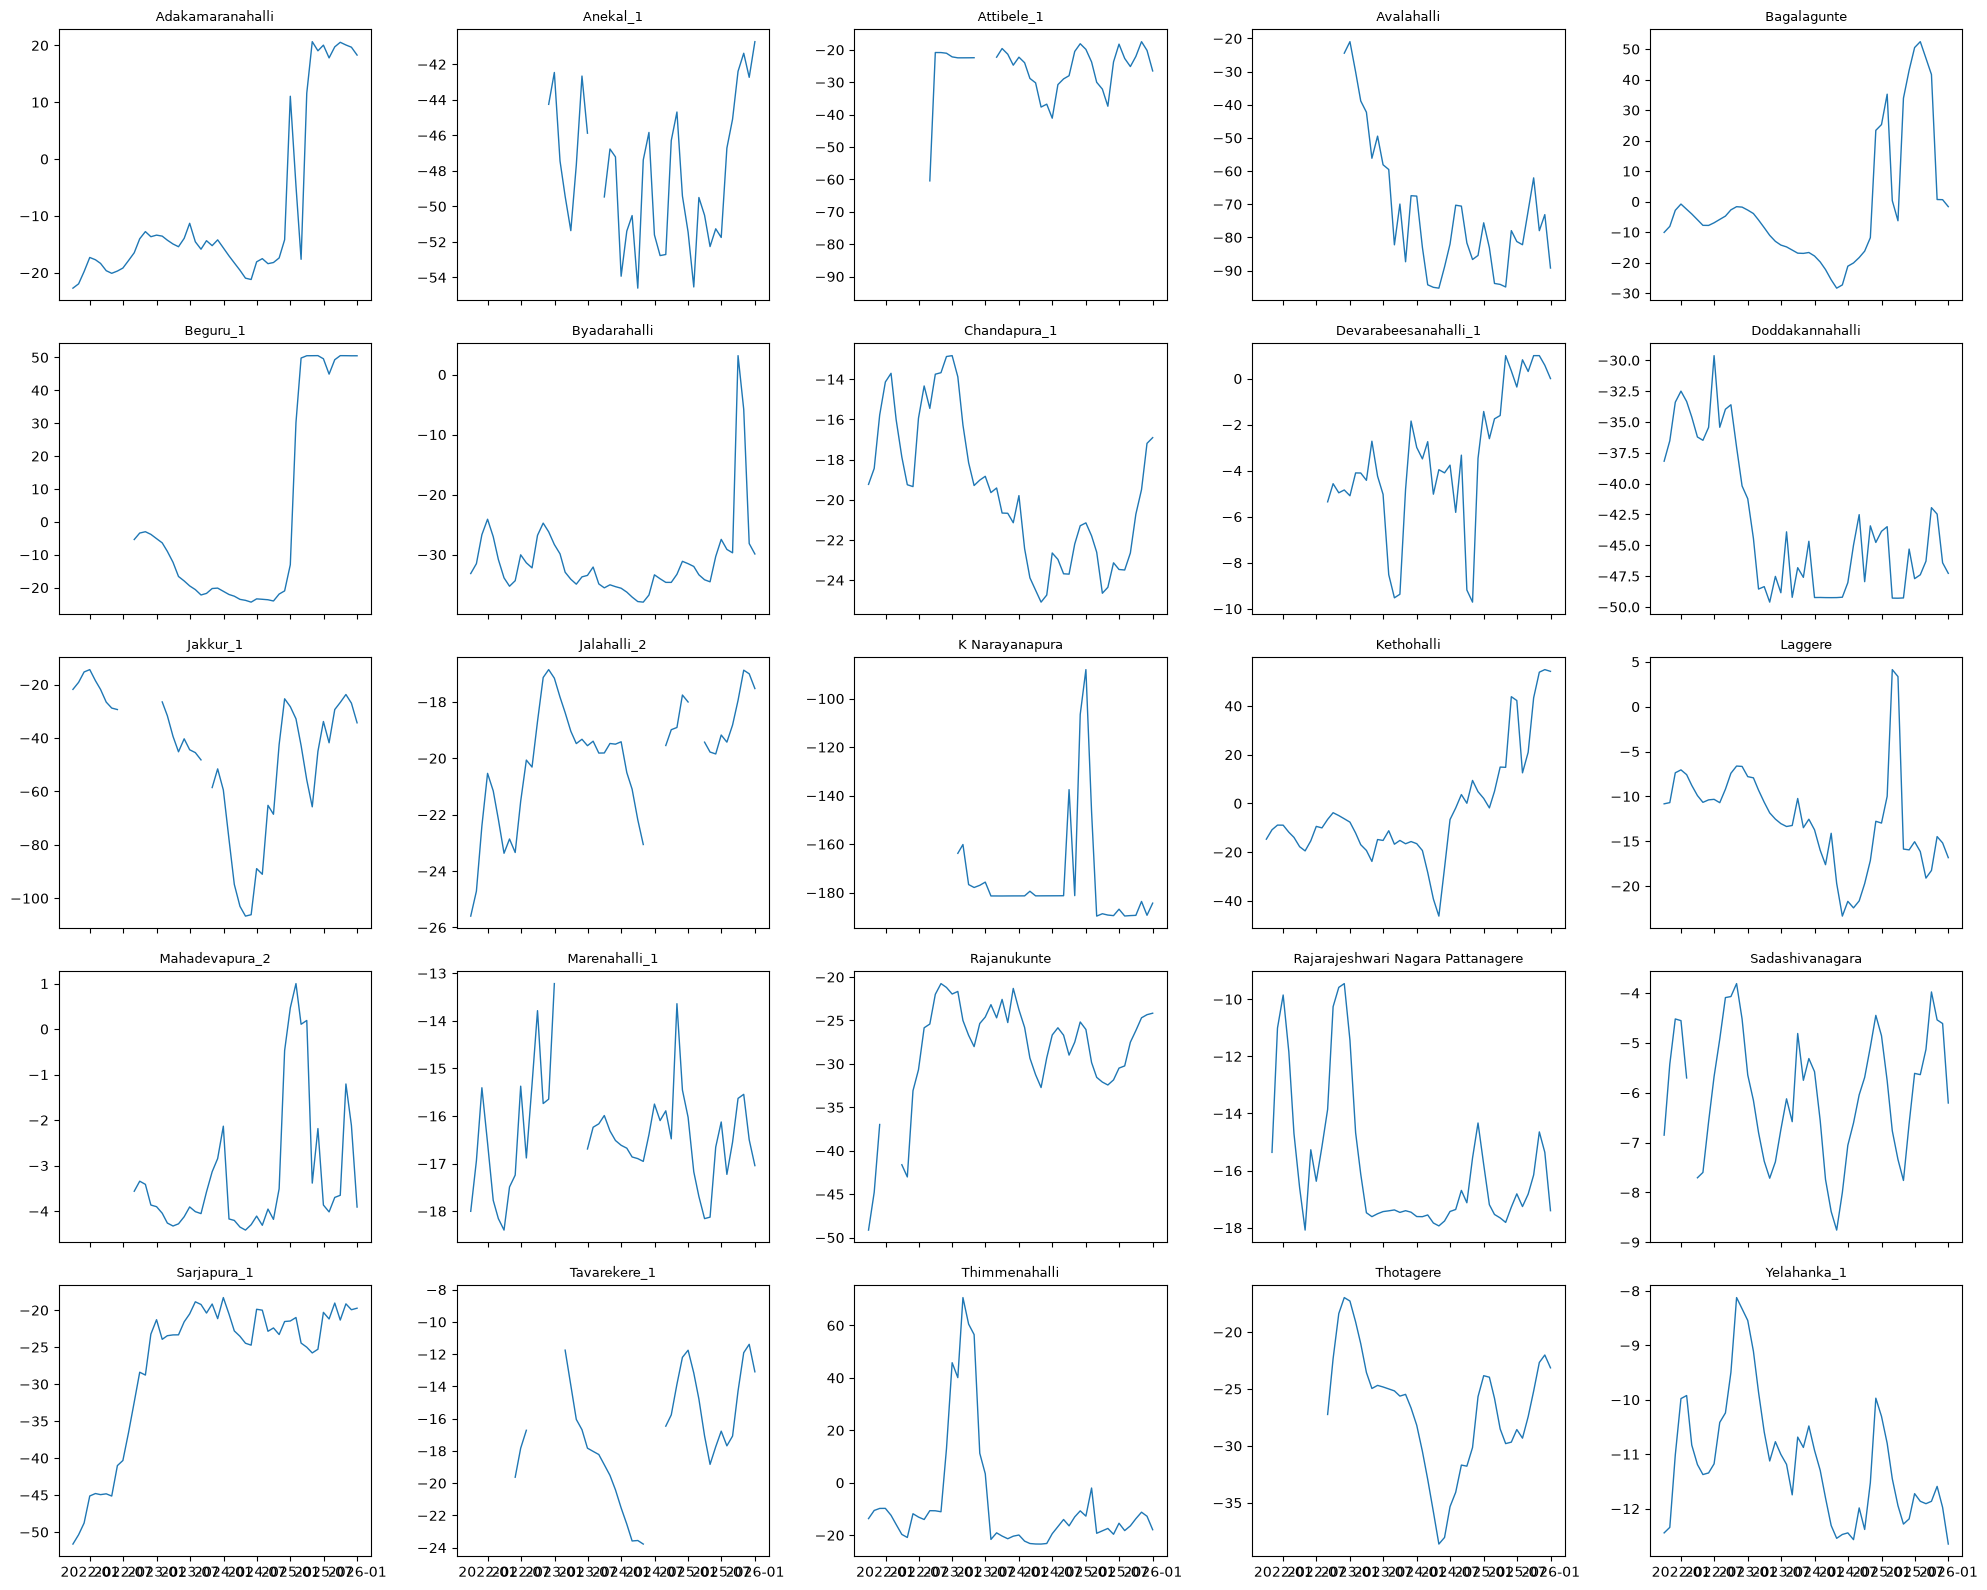

In [13]:
import matplotlib.pyplot as plt

stations = sorted(df["Station"].unique())

fig, axes = plt.subplots(5, 5, figsize=(20, 16), sharex=True)

axes = axes.flatten()

for ax, station in zip(axes, stations):

    station_data = df[df["Station"] == station]

    monthly = (
        station_data
        .set_index("Data Acquisition Time")
        .resample("ME")["Groundwater Level Telemetry 6 Hourly (meter)"]
        .mean()
    )

    ax.plot(monthly.index,
            monthly.values,
            linewidth=1)

    ax.set_title(station, fontsize=9)

# Remove unused axes if any
for i in range(len(stations), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()

In [14]:
station_trend = (
    df.groupby("Station")["Groundwater Level Telemetry 6 Hourly (meter)"]
      .agg(["mean", "std", "min", "max"])
      .sort_values("mean")
)

display(station_trend.round(2))

,mean,std,min,max
Station,,,,
K Narayanapura,-174.76,38.55,-190.11,1.00
Avalahalli,-74.55,33.46,-95.49,1.00
Jakkur_1,-48.96,27.80,-112.35,1.00
Anekal_1,-48.25,5.41,-63.47,1.00
Doddakannahalli,-44.39,9.49,-50.34,1.00
Byadarahalli,-31.45,9.05,-37.96,48.36
Rajanukunte,-27.39,8.92,-49.19,1.00
Thotagere,-26.83,5.36,-39.76,1.00
Attibele_1,-26.82,12.30,-93.60,1.00


### Interpretation

The station-wise temporal analysis demonstrates substantial spatial heterogeneity in groundwater behavior.

Key observations include:

- Stations such as **Mahadevapura_2**, **Marenahalli_1**, **Yelahanka_1**, and **Sadashivanagara** exhibit relatively stable groundwater levels with low variability.

- **K Narayanapura** consistently records the deepest groundwater levels, with an average of approximately **−175 m**, making it an extreme station compared to the remaining network.

- **Beguru_1**, **Bagalagunte**, **Kethohalli**, and **Thimmenahalli** show large temporal fluctuations, indicating substantial seasonal changes or operational effects.

- Several stations display abrupt level shifts, which may correspond to recharge periods, groundwater extraction, maintenance events, or local hydrogeological differences.

- The observed station-specific differences confirm that groundwater behavior is highly location-dependent and justify incorporating station identity as an important predictive feature during model development.

## Step 4.4 – Seasonal Analysis

Groundwater levels are expected to vary across seasons due to rainfall, recharge, evaporation, and groundwater extraction.

This analysis groups observations into meteorological seasons and compares groundwater levels to identify seasonal recharge and depletion patterns.

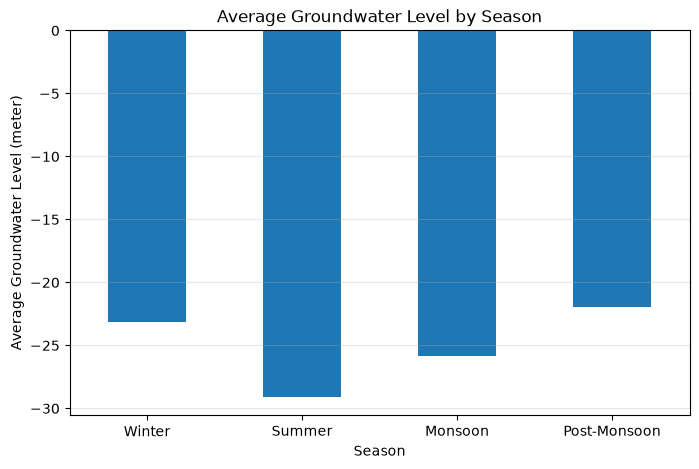

,mean,median,std,min,max
Season,,,,,
Winter,-23.14,-17.57,33.97,-190.02,78.94
Summer,-29.11,-22.19,39.15,-189.69,79.03
Monsoon,-25.83,-18.39,36.68,-190.11,79.01
Post-Monsoon,-21.96,-16.67,33.70,-189.42,54.98


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["Data Acquisition Time"].dt.month.apply(get_season)

season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]

season_stats = (
    df.groupby("Season")["Groundwater Level Telemetry 6 Hourly (meter)"]
      .agg(["mean", "median", "std", "min", "max"])
      .reindex(season_order)
      .round(2)
)

plt.figure(figsize=(8,5))

season_stats["mean"].plot(
    kind="bar",
    rot=0
)

plt.ylabel("Average Groundwater Level (meter)")
plt.title("Average Groundwater Level by Season")
plt.grid(axis="y", alpha=0.3)

plt.show()

display(season_stats)

### Interpretation

The seasonal analysis reveals a clear annual pattern in groundwater levels across the monitoring network.

Key observations include:

- **Summer** records the lowest average groundwater level (**−29.11 m**), indicating the greatest groundwater depletion during the dry season.
- Groundwater levels begin to recover during the **Monsoon** season, with the average improving to **−25.83 m**, reflecting aquifer recharge from rainfall.
- **Winter** shows a further improvement, with an average groundwater level of **−23.14 m**.
- The **Post-Monsoon** season exhibits the shallowest average groundwater level (**−21.96 m**), suggesting that groundwater recharge continues after the monsoon period.

Additional observations:

- Seasonal variability remains relatively high (standard deviation ranging from **33.70 m** to **39.15 m**) because the dataset combines measurements from 25 stations with substantially different groundwater depths.
- The deepest recorded values (approximately **−190 m**) appear across multiple seasons, indicating that these represent consistently deep monitoring locations rather than seasonal anomalies.

Overall, the results confirm that groundwater levels exhibit a distinct seasonal cycle, with depletion during summer followed by progressive recovery through the monsoon, winter, and post-monsoon periods. This supports the inclusion of seasonal features in subsequent feature engineering and predictive modeling.

## Step 4.5 – Year-wise Trend Analysis

Groundwater levels may exhibit long-term trends resulting from changing rainfall patterns, groundwater abstraction, urbanization, and aquifer recharge.

This analysis examines the average groundwater level for each year to identify long-term increasing or decreasing trends across the monitoring period.

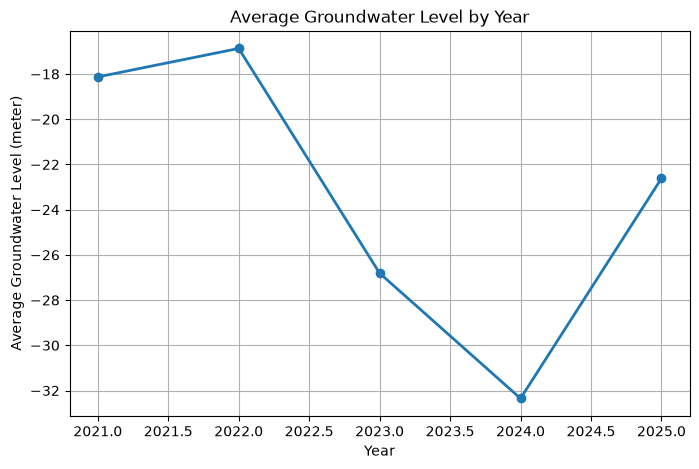

,mean,median,std,min,max,count
Year,,,,,,
2021,-18.13,-15.26,12.39,-53.49,-0.04,4163
2022,-16.87,-16.32,13.50,-93.60,62.46,17139
2023,-26.81,-18.96,36.52,-181.46,79.03,27471
2024,-32.35,-23.02,37.61,-181.36,54.86,26905
2025,-22.62,-17.62,45.34,-190.11,63.54,23767


In [16]:
import matplotlib.pyplot as plt

# Extract year
df["Year"] = df["Data Acquisition Time"].dt.year

# Compute yearly statistics
yearly_stats = (
    df.groupby("Year")["Groundwater Level Telemetry 6 Hourly (meter)"]
      .agg(["mean", "median", "std", "min", "max", "count"])
      .round(2)
)

# Plot yearly mean groundwater level
plt.figure(figsize=(8,5))

plt.plot(
    yearly_stats.index,
    yearly_stats["mean"],
    marker="o",
    linewidth=2
)

plt.title("Average Groundwater Level by Year")
plt.xlabel("Year")
plt.ylabel("Average Groundwater Level (meter)")
plt.grid(True)

plt.show()

display(yearly_stats)

### Observations

- Average groundwater levels varied across the study period.
- 2022 recorded the shallowest average groundwater level (-16.87 m).
- 2024 showed the deepest average groundwater level (-32.35 m).
- Groundwater levels partially recovered during 2025.
- Increased standard deviation in later years indicates higher variability across monitoring stations.
- Differences in yearly averages are influenced by varying station availability and should be interpreted with caution.

## 4.6 Station-wise Overall Trend

To understand long-term groundwater behaviour, the average groundwater level is computed separately for each monitoring station over time.

This analysis helps identify:

- Stations showing long-term decline
- Stations showing groundwater recovery
- Stable monitoring stations
- Station-specific temporal behaviour

These plots are useful because groundwater dynamics vary significantly across locations and should not be interpreted only from the overall city-wide average.

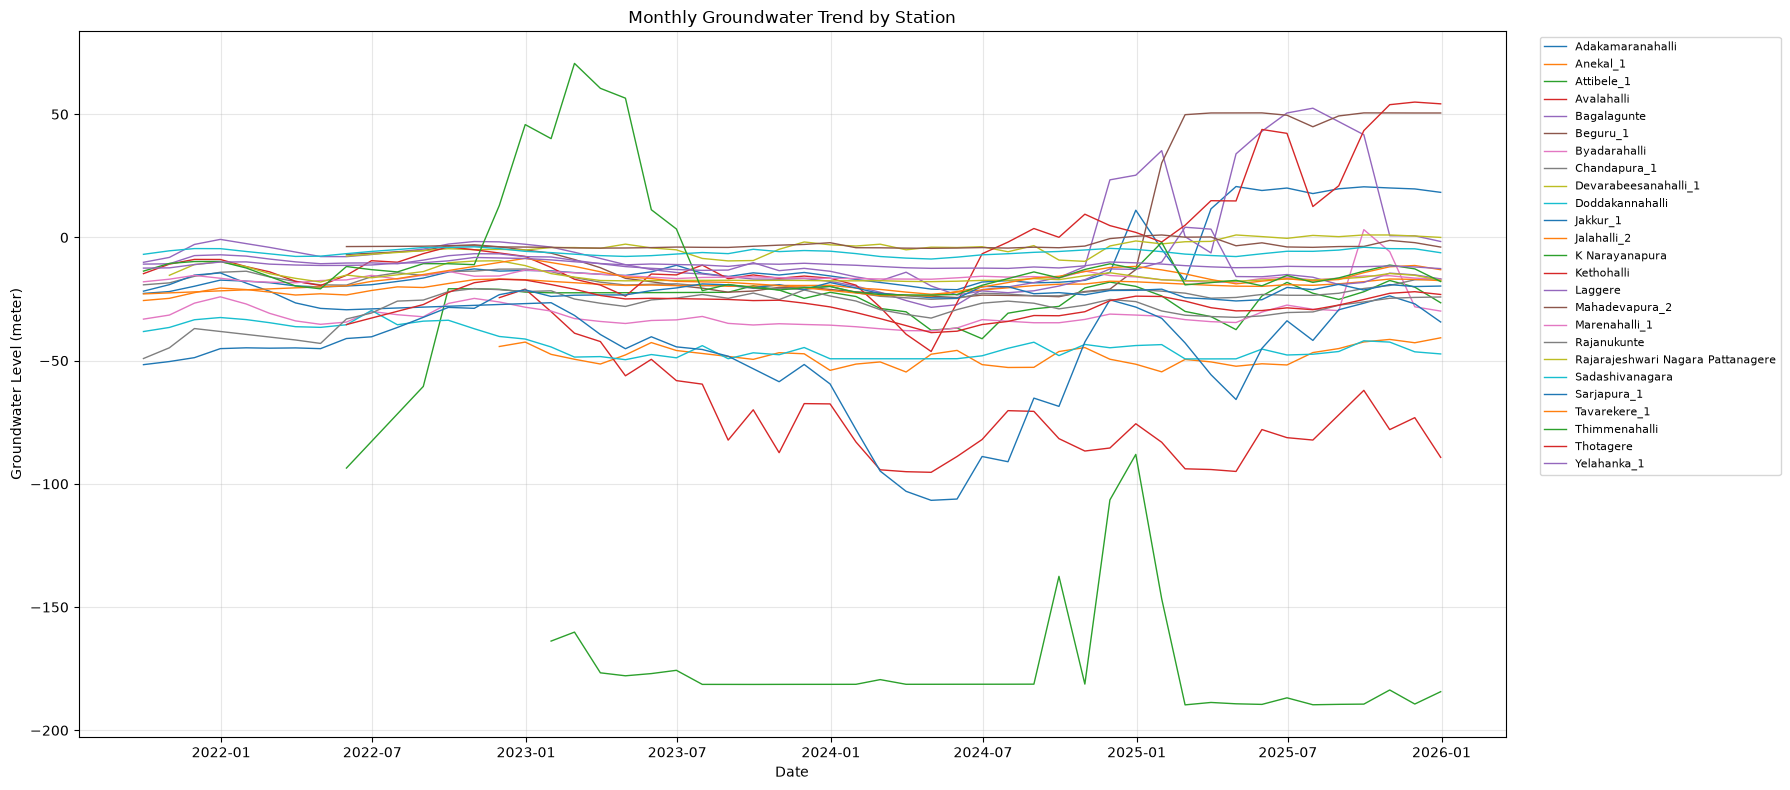

In [17]:
# Monthly average groundwater level for each station

station_monthly = (
    df.groupby([
        'Station',
        pd.Grouper(
            key='Data Acquisition Time',
            freq='ME'
        )
    ])['Groundwater Level Telemetry 6 Hourly (meter)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(18,8))

for station in station_monthly['Station'].unique():
    temp = station_monthly[
        station_monthly['Station'] == station
    ]

    plt.plot(
        temp['Data Acquisition Time'],
        temp['Groundwater Level Telemetry 6 Hourly (meter)'],
        label=station,
        linewidth=1
    )

plt.title("Monthly Groundwater Trend by Station")
plt.xlabel("Date")
plt.ylabel("Groundwater Level (meter)")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc='upper left',
    fontsize=8
)

plt.tight_layout()
plt.show()

In [18]:
# Overall monthly trend statistics

station_monthly_summary = (
    station_monthly.groupby('Station')
    ['Groundwater Level Telemetry 6 Hourly (meter)']
    .agg([
        'mean',
        'std',
        'min',
        'max'
    ])
    .sort_values('mean')
)

station_monthly_summary.round(2)

,mean,std,min,max
Station,,,,
K Narayanapura,-174.93,22.27,-189.67,-88.04
Avalahalli,-72.24,20.11,-95.31,-20.97
Anekal_1,-48.22,3.93,-54.60,-40.73
Jakkur_1,-46.44,25.75,-106.68,-14.40
Doddakannahalli,-43.35,5.87,-49.61,-29.62
Byadarahalli,-31.02,6.93,-37.91,3.16
Rajanukunte,-28.35,6.15,-49.13,-20.75
Attibele_1,-27.77,13.51,-93.58,-17.47
Sarjapura_1,-27.12,9.84,-51.62,-18.29


## Interpretation

The station-wise monthly trends reveal substantial spatial and temporal variation in groundwater levels across Bengaluru.

K Narayanapura consistently recorded the deepest groundwater levels (around -175 m) throughout the study period, making it the most groundwater-stressed station.
Avalahalli, Jakkur_1, and Doddakannahalli also exhibited relatively deep groundwater levels compared to most other stations.
Stations such as Beguru_1, Bagalagunte, and Kethohalli showed pronounced upward shifts during later years, indicating significant temporal changes that may reflect groundwater recharge, local hydrological conditions, or sensor-related variations.
Sadashivanagara, Mahadevapura_2, Devarabeesanahalli_1, and Yelahanka_1 remained comparatively stable with low month-to-month variability.
The variability statistics indicate that Beguru_1 (Std ≈ 30.49 m), Jakkur_1 (25.75 m), Kethohalli (22.66 m), and Thimmenahalli (22.15 m) experienced the greatest temporal fluctuations.
Overall, groundwater behaviour differs considerably among monitoring stations, supporting the inclusion of station identity and spatial information during feature engineering and predictive modelling.

# Conclusion

In this notebook, a comprehensive Exploratory Data Analysis (EDA) was performed on the cleaned groundwater monitoring dataset.

The analysis provided insights into the statistical distribution of groundwater levels, station-wise variations, temporal trends, seasonal behaviour, and yearly changes across Bengaluru monitoring stations. Significant differences were observed among stations, indicating strong spatial heterogeneity in groundwater conditions. Temporal analysis also revealed noticeable monthly and seasonal patterns, while yearly analysis highlighted changes in groundwater levels over the study period.

Key observations from this notebook include:

- The dataset contains substantial variability across monitoring stations.
- Several stations exhibit consistently deep groundwater levels, while others remain comparatively shallow.
- Seasonal and monthly patterns suggest groundwater fluctuations throughout the year.
- Some stations demonstrate stable behaviour, whereas others experience considerable temporal variation.
- These findings indicate that both temporal and spatial characteristics should be incorporated into predictive models.

The insights obtained from this exploratory analysis provide a strong foundation for the next stage of the project, where meaningful machine learning features will be engineered to improve groundwater level prediction.

